# Connectivity

In [1]:
import pandas as pd
import numpy as np
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

from utils import OUT_PATH, GetInfo, ExcludSubj

tfr_path = OUT_PATH+ '/Data_longWOBS'
subj_included = [file.replace('_TFRtrials.p', '') for file in os.listdir(tfr_path) if file[-len('TFRtrials.p'):] == 'TFRtrials.p']
subj_included = ExcludSubj(subj_included, data_path=tfr_path)
print(f"Subject Nbr is {len(subj_included)}")

path = tfr_path + f'/{subj_included[0]}_info.json'
with open(path) as json_data:
    d = json.load(json_data)
    time_tfr=d['time_tfr']
     
_, _, _, subj_list, regions = GetInfo(subj_included, data_path=tfr_path)

events = ['old/correct', 'new/correct']
band = 'high_gamma'
pc='compo3'
switch_id = 68 # 0.75s
weight = pd.read_csv(OUT_PATH + '/grpPCA/supsubj_concat/grp_concat_Compo_PCA5.csv').query('freq == @band & compo == @pc').drop(columns = ['Unnamed: 0', 'freq', 'compo']).values[0, :]
data_ch = pd.DataFrame()
data_ch['ch1'] = np.where(abs(weight) > abs(weight).mean() + abs(weight).std(), True, False)
data_ch['subj'] = subj_list
data_ch['ROIs'] = regions
rois = data_ch[data_ch['ch1'] == True]['ROIs'].values

Subject Nbr is 30


In [ ]:
# compute the all first and then see if diff before and after the switch
switch_timing_compo3 = {'old/correct' :  67, 'new/correct' : 63, 'decoding' : 67 }

In [ ]:
# import data
events = ['old/correct', 'new/correct']
band = 'high_gamma'
pc='compo3'
method= 'pear'
ev=events[1]
con = pd.read_csv(OUT_PATH + f'/Connectivity/{band}/pear_{pc}_{ev[:3]}_all.csv').set_index('rois')


<Axes: ylabel='rois'>

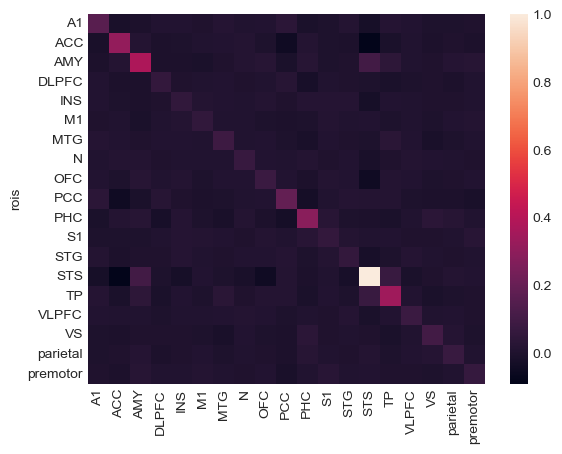

In [ ]:
sns.heatmap(con)

In [12]:
# set the metric a link of the network 
G_before = nx.Graph()
G_before.add_nodes_from(rois)
for r1 in rois : 
    for r2 in rois :
        G_before.add_edge(r1, r2, weight=con_before)

centralityb = nx.degree_centrality(G_before)
bentralityb = nx.betweenness_centrality(G_before)
#global_efficiencyb = nx.global_efficiency(G_before)
#worldnesb = nx.sigma(G_before)


## Exploration other metrics

In [ ]:
import pandas as pd
import numpy as np
import json
import os
import pickle
from scipy.stats import spearmanr, pearsonr


from utils import OUT_PATH, GetInfo, ExcludSubj, FREQ_BAND, EVENT_ID

tfr_path = OUT_PATH+ '/Data_longWOBS'
subj_included = [file.replace('_TFRtrials.p', '') for file in os.listdir(tfr_path) if file[-len('TFRtrials.p'):] == 'TFRtrials.p']
subj_included = ExcludSubj(subj_included, data_path=tfr_path)

path = tfr_path + f'/{subj_included[0]}_info.json'
with open(path) as json_data:
    d = json.load(json_data)
    time_tfr=d['time_tfr']
     
_, _, _, subj_list, regions = GetInfo(subj_included, data_path=tfr_path)

events = ['old/correct', 'new/correct']
band = 'high_gamma'
pc='compo3'
weight = pd.read_csv(OUT_PATH + '/grpPCA/supsubj_concat/grp_concat_Compo_PCA5.csv').query('freq == @band & compo == @pc').drop(columns = ['Unnamed: 0', 'freq', 'compo']).values[0, :]
data_ch = pd.DataFrame()
data_ch['ch1'] = np.where(abs(weight) > abs(weight).mean() + abs(weight).std(), True, False)
data_ch['subj'] = subj_list
data_ch['ROIs'] = regions

rois = data_ch[data_ch['ch1'] == True]['ROIs'].values


Subject Nbr is 30


In [34]:
from scipy.signal import hilbert, butter, sosfiltfilt

def bandpass(data: np.ndarray, edges: list[float], sample_rate: float, poles: int = 5):
    sos = butter(poles, edges, 'bandpass', fs=sample_rate, output='sos')
    filtered_data = sosfiltfilt(sos, data)
    return filtered_data

In [42]:
param_filter={'high_gamma' : [55, 99]}
spl_rate =200

trials_env ={ev:[] for ev in events}
trials_phase ={ev:[] for ev in events}

for subj in np.unique(subj_list)[:1]:
    data_subj = data_ch.query('subj == @subj').reset_index()
    ch = data_subj.query("ch1 == True").index

    file = tfr_path + f'/{subj}_epochs.p'
    with open(file, "rb") as f:
        tr = pickle.load(f)
        analog_env = np.zeros_like(tr)
        analog_phase = np.zeros_like(tr)
        for c in range(tr.shape[1]) : 
            for e in range(tr.shape[0]) :
                analog = hilbert(bandpass(tr[e, c,:], param_filter[band], spl_rate))
                analog_env[e, c, :] = abs(analog)
                analog_phase[e, c, :] = np.angle(analog) 

    info_file = tfr_path + f'/{subj}_info.json'
    with open(info_file) as f:
         info = json.load(f)
         events_index = np.array([int(i) for i in info['event_id']])

    id_ch = np.array(ch)
    for ev in events : 
        id_ev = np.where(events_index == EVENT_ID[ev])[0]

        if len(id_ch) == 0 : 
            continue
        tr_band_env = analog_env[np.ix_(id_ev, id_ch, range(tr.shape[-1]))]
        tr_band_phase = analog_phase[np.ix_(id_ev, id_ch, range(tr.shape[-1]))]

        trials_env[ev].append(tr_band_env)
        trials_phase[ev].append(tr_band_phase)



## With Mutual info -- don't work too small sample even lumping the Rois elect

In [75]:
from sklearn.neighbors import NearestNeighbors
from scipy.special import digamma

# k The number of nearest neighbors used to estimate local probability density around each sample point.
def kraskov_mi(x, y, k=5):
    xy = np.column_stack((x, y))
    n = len(x)

    nbrs = NearestNeighbors(n_neighbors=k+1, metric='chebyshev')
    nbrs.fit(xy)
    distances, _ = nbrs.kneighbors(xy)
    eps = distances[:, k]  

    nx = []
    ny = []

    for i in range(n):
        nx.append(np.sum(np.abs(x - x[i]) < eps[i]) - 1)
        ny.append(np.sum(np.abs(y - y[i]) < eps[i]) - 1)

    nx = np.array(nx)
    ny = np.array(ny)

    mi = digamma(k) + digamma(n) - np.mean(digamma(nx+1) + digamma(ny+1))
    return mi


In [76]:
# first time window : before switch
data_b = {ev:[] for ev in events}
for ev in events :
    for tr in trials[ev] : 
        data_b[ev].extend([tr[:,c, 0,25:switch_id] for c in range(tr.shape[1])])


In [77]:
# concat all the electrods of the same area to use mi
data_b_r = {ev:{r: [] for r in regions} for ev in events}

for ev in events :
    min_ = []
    d_r = {r: [] for r in regions} 
    for r in np.unique(regions) :
        id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
        if len(id_) == 0 : 
            min_.append(0)
            continue
        for i in id_ : 
            d_r[r].append(data_b[ev][i])

        min_.append(np.min([len(d_r[r][i]) for i in range(len(d_r[r]))]))

    for ir, r in enumerate(np.unique(regions)) :
        id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
        l = [d_r[r][i][:min_[ir]] for i in range(len(d_r[r])) if min_[ir] != 0]
        if len(l) != 0 :
            data_b_r[ev][r] = np.vstack(l)

/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_4370/2514667255.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_4370/2514667255.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_4370/2514667255.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
/var/folders/rr/sx7rgrrj3p12hz70crvxqcjc0000gn/T/ipykernel_4370/2514667255.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  id_ = data_ch[data_ch['ch1'] == True].reset_index()[data_ch['ROIs'] == r].index.values
/var/folders/rr/

In [82]:
# at Rois level
Mi_b = np.zeros([len(data_b_r['old/correct']), len(data_b_r['old/correct'])])

for k in [1, 2, 3, 4] :
    for i,items_x in enumerate(data_b_r['old/correct'].items()):
        xk, xv= items_x
        if len(xv) == 0 :
            continue

        for j,items_y in enumerate(data_b_r['old/correct'].items()) :
            yk, yv= items_y
            if len(yv) == 0 :
                continue
            min_trial = np.min([xv.shape[0], yv.shape[0]])
            
            Mi_b[i, j] = kraskov_mi(xv[:min_trial, :], yv[:min_trial, :], k=k)
    
    print(np.min(Mi_b), np.max(Mi_b))


-14.057431094112868 0.0
-13.123090717732214 0.0
-12.652577306626188 0.0
-12.339663171533523 0.0


In [62]:
# first time window : before switch
data_a = {ev:[] for ev in events}
for ev in events :
    for tr in trials[ev] : 
        data_a[ev].extend([tr[:,c, 0,switch_id:120] for c in range(tr.shape[1])])

Mi_a = np.zeros([len(data_a['old/correct']), len(data_a['old/correct'])])
for i,x in enumerate(data_a['old/correct']):
    for j,y in enumerate(data_a['old/correct']) :
        min_trial = np.min([x.shape[0], y.shape[0]])
        Mi_a[i, j] = kraskov_mi(x[:min_trial, :], y[:min_trial, :], k=5)



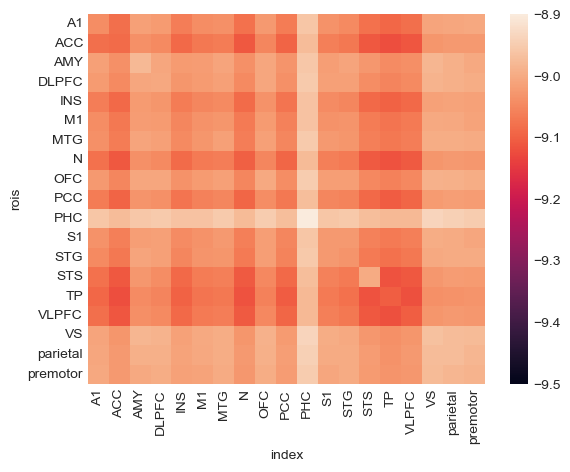

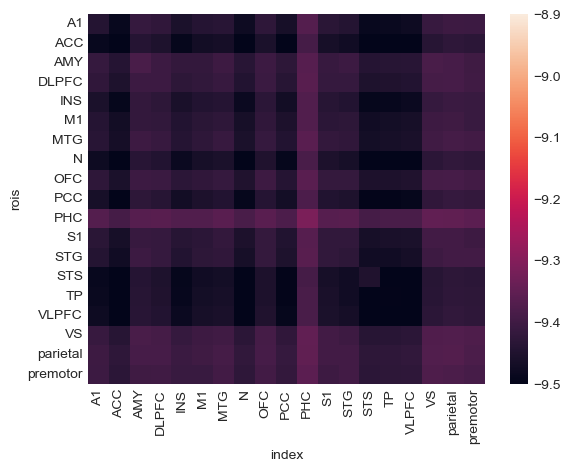

In [65]:
rois = data_ch[data_ch['ch1'] == True]['ROIs'].values

for mi in [Mi_b, Mi_a] : 
    df_Mi = pd.DataFrame(mi, columns = rois)
    df_Mi['rois'] = rois
    df_Mi= df_Mi.set_index('rois')
    df_Mi = df_Mi.reset_index().groupby('rois').mean().T.reset_index().groupby('index').mean().T

    sns.heatmap(df_Mi, vmin= -9.5, vmax = -8.9)
    plt.show()